# Reuters Evaluation

In [1]:
import os 
import sys
import pickle as pkl

import jax
import jax.numpy as jnp
from jax.nn import softmax


project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils.plots import plot_roles, plot_adjacency_matrix
from utils.utils import compute_best_permutation, l1_loss

from models.dMMSB import jitdMMSB


## Load data

In [2]:
# with open("../data/reuters/dict_nodes.pkl", "rb") as f:
#     dict_nodes = pkl.load(f)

with open("../data/reuters/subgraph.pkl", "rb") as f:
    E = pkl.load(f)

In [3]:
T, N, _ = E.shape
K = 2

In [4]:
E = jnp.where(E > 0, 1, 0) # Binarize edges

In [6]:
restarts = 5

best_model = None
best_ll = -jnp.inf
for run in range(restarts):
    print(f"Run {run+1}")

    model = jitdMMSB(nodes=N, roles=K, timesteps=T, key=jax.random.PRNGKey(100+run))
    ll = model.fit(E, max_inner_iters=1000, max_outer_iters=200, tol=1e-6, verbose=True)

    if ll > best_ll:
        best_ll = ll
        best_model = model
    print(f"Current ll:{ll} | Best ll:{best_ll}")

Run 1
Best initialization log-likelihood: -115930.63
Current ll:-27.180004119873047 | Best ll:-27.180004119873047
Run 2
Best initialization log-likelihood: -71525.68
Current ll:-27.180334091186523 | Best ll:-27.180004119873047
Run 3
Best initialization log-likelihood: -11762.749
Current ll:-27.182092666625977 | Best ll:-27.180004119873047
Run 4
Best initialization log-likelihood: -63151.438
Current ll:-27.182973861694336 | Best ll:-27.180004119873047
Run 5
Best initialization log-likelihood: -84700.32
Current ll:-27.182403564453125 | Best ll:-27.180004119873047


In [7]:
jnp.set_printoptions(precision=3, suppress=True)
print("Best Model Role Matrix:")
print(best_model.B)

Best Model Role Matrix:
[[0. 0.]
 [0. 1.]]


Timestep 1


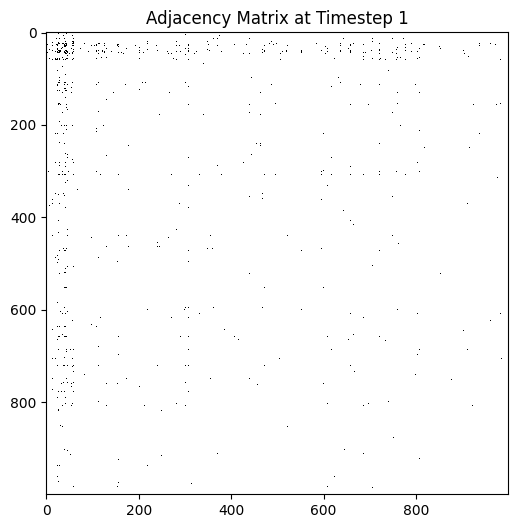

Timestep 2


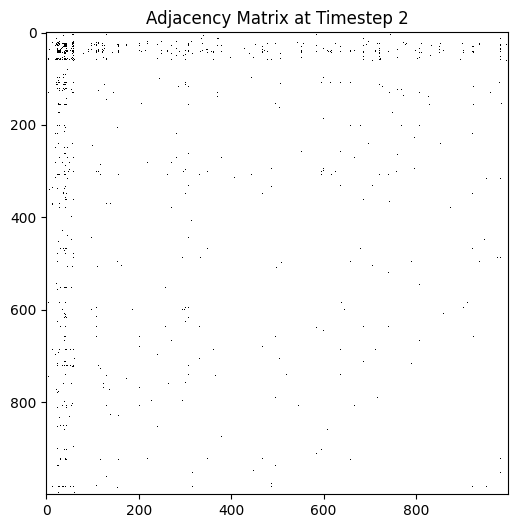

Timestep 3


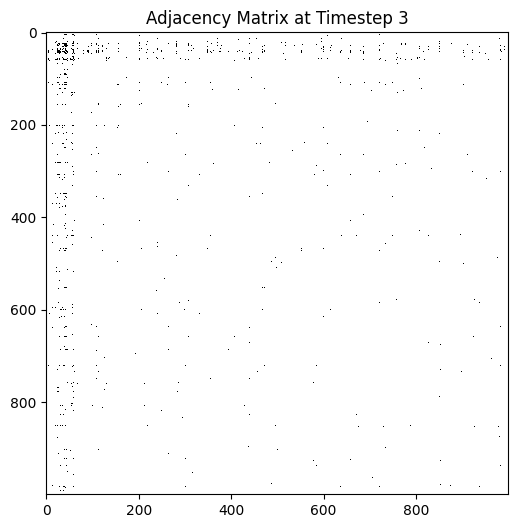

Timestep 4


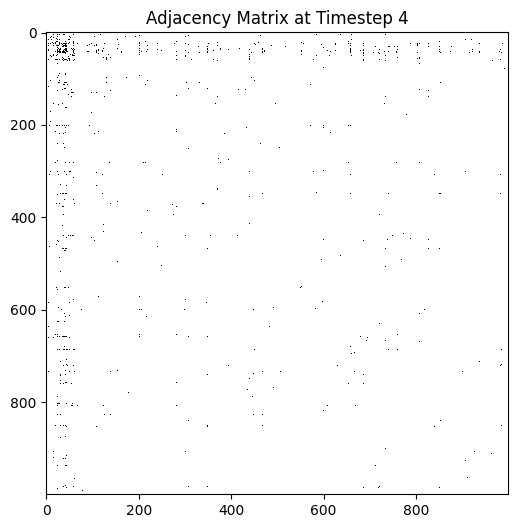

Timestep 5


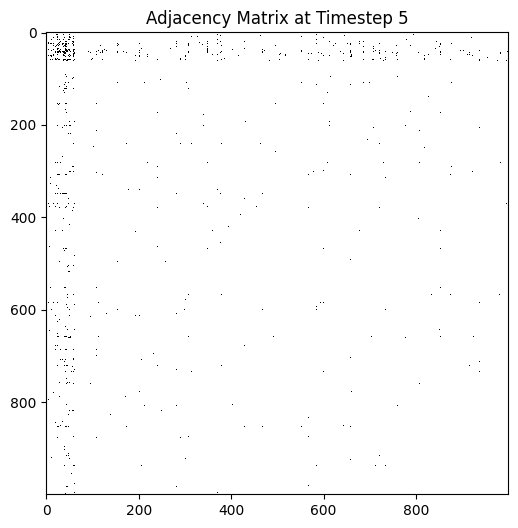

Timestep 6


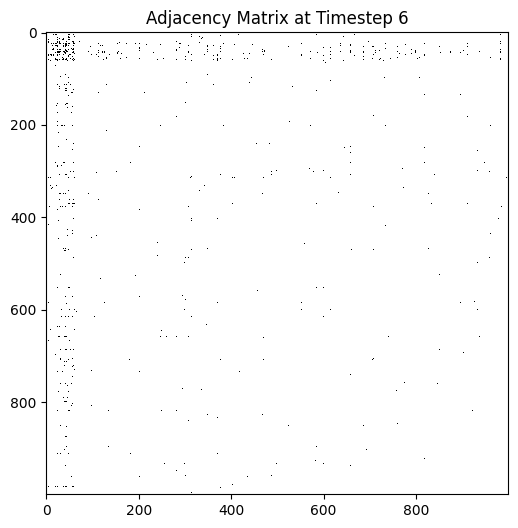

In [8]:
for t in range(T):
    print(f"Timestep {t+1}")
    plot_adjacency_matrix(E[t], title=f"Adjacency Matrix at Timestep {t+1}")